# Germline model postprocessing

This notebook loads the saved germline LSD checkpoint from `./germline_model`, computes `final_adata`, and measures CBDir on the UMAP embedding.

In [1]:
import glob
import os

import numpy as np
import pandas as pd
import scanpy as sc
import torch
from cellrank.kernels import ConnectivityKernel
from cellrank.kernels.utils import TmatProjection

from sclsd.analysis import cross_boundary_correctness
from sclsd.core import LSDConfig
from sclsd.train import LSD
from sclsd.utils import set_all_seeds
from sclsd.utils.seed import clear_pyro_state

SEED = 42
set_all_seeds(SEED)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:1


In [2]:
adata = sc.read("../../Zenodo/Human_germline/preprocessed_adata.h5ad")


phylogeny = {
    "primordial germ cell": ["germ cell"],
    "germ cell": ["male germ cell", "oogonial cell"],
    "oogonial cell": ["oocyte"],
    "male germ cell": [],
}

cfg = LSDConfig()
cfg.walks.random_state = SEED


lsd = LSD(adata, cfg, device=device)

model_dir = "./model"
checkpoint_files = sorted(glob.glob(os.path.join(model_dir, "lsd_model_epoch*.pth")))

latest_checkpoint = os.path.basename(checkpoint_files[-1])
print(f"Loading checkpoint: {latest_checkpoint}")
clear_pyro_state()
lsd.load(dir_path=model_dir, file_name=latest_checkpoint)

final_adata = lsd.get_adata()
final_adata
dyn_adata = lsd.get_cell_fates(final_adata, time_range = 5,cluster_key = "clusters", batch_size= 2048)

Loading checkpoint: lsd_model_epoch0120.pth
[LSD] Model and Pyro parameters loaded from ./model/lsd_model_epoch0120.pth


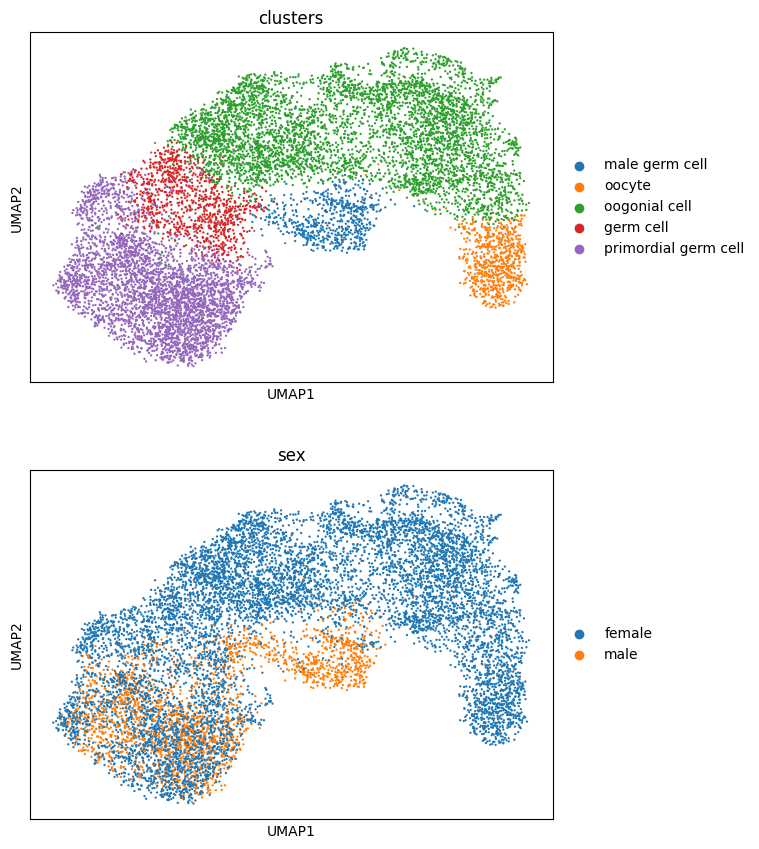

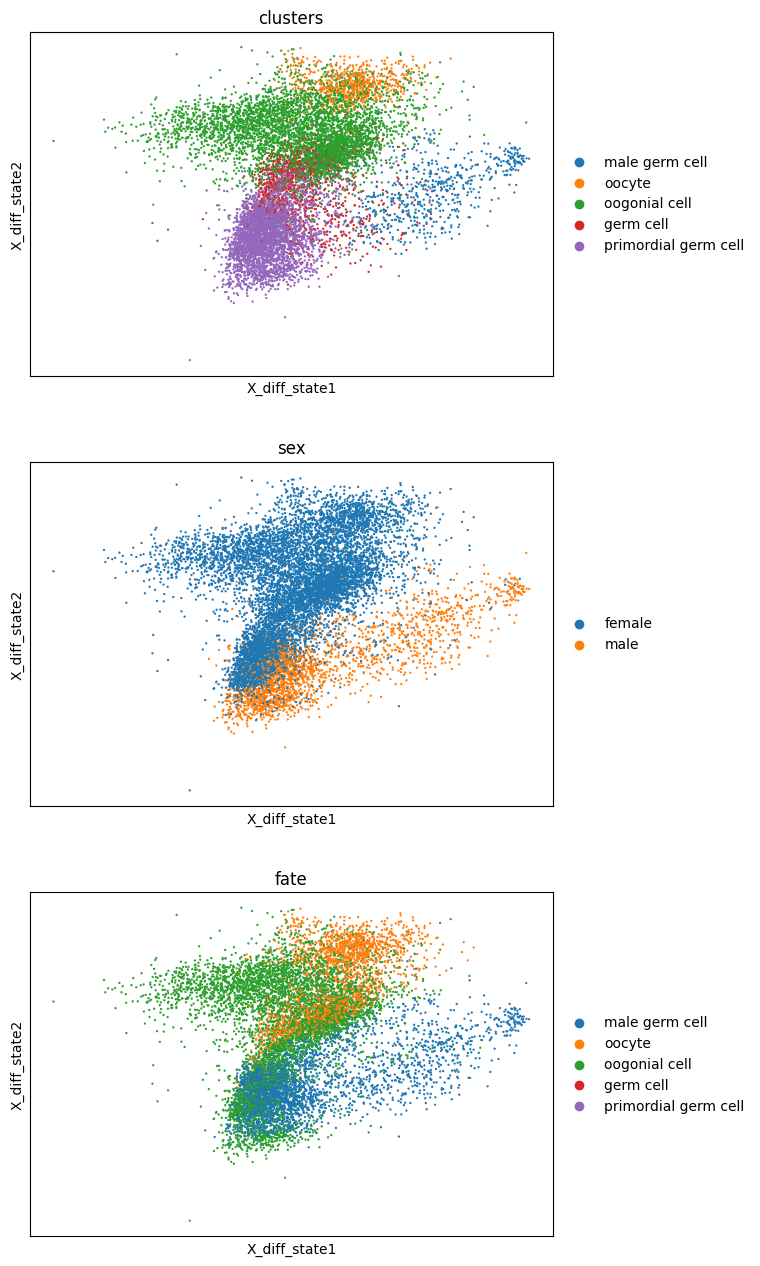

In [3]:
sc.pl.umap(final_adata, color = ["clusters", "sex"], ncols = 1)
sc.pl.embedding(dyn_adata, color = ["clusters", "sex","fate"], basis = "X_diff_state", ncols = 1)

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fates = [
    "primordial germ cell",
    "germ cell",
    "male germ cell",
    "oogonial cell",
    "oocyte",
]

obs = dyn_adata.obs.copy()

# Keep only the fates you care about
obs = obs[obs["fate"].isin(fates)].copy()
obs = obs[obs["clusters"].isin(["primordial germ cell","germ cell"])]
# Counts: rows = sex, columns = fate
count_matrix = pd.crosstab(
    obs["sex"],
    obs["fate"],
).reindex(index=["female", "male"], columns=fates, fill_value=0)

# Percentages within each sex
percent_matrix = count_matrix.div(count_matrix.sum(axis=1), axis=0) * 100

percent_matrix

fate,primordial germ cell,germ cell,male germ cell,oogonial cell,oocyte
sex,,,,,
female,0.033535,0.033535,39.906103,48.122066,11.904762
male,0.056338,0.000000,68.169014,31.492958,0.281690


In [8]:
cluster_edges = [
    ("primordial germ cell", "germ cell"),
    ("germ cell", "male germ cell"),
    ("germ cell", "oogonial cell"),
    ("oogonial cell", "oocyte"),
]

final_adata.obsm["X_umap_eval"] = np.asarray(final_adata.obsm["X_umap"])

kernel = ConnectivityKernel(final_adata)
kernel.transition_matrix = final_adata.obsp["transitions"]

proj = TmatProjection(kernel, basis="X_umap_eval")
proj.project(
    key_added="velocity_umap",
    recompute=True,
    connectivities=final_adata.obsp["connectivities"],
)

final_adata.uns.setdefault("neighbors", {})
final_adata.uns["neighbors"]["indices"] = final_adata.obsp["distances"].tolil().rows

all_scores, mean_cbdir = cross_boundary_correctness(
    final_adata,
    k_cluster="clusters",
    k_velocity="velocity_umap",
    cluster_edges=cluster_edges,
    x_emb="X_umap_eval",
)

cbdir_df = pd.DataFrame(
    {
        "edge": [f"{src}->{dst}" for src, dst in all_scores],
        "cbdir": list(all_scores.values()),
    }
)

print("Cross-boundary correctness scores:")
for edge, score in all_scores.items():
    print(f"  {edge}: {score:.3f}")
print(f"\nOverall average: {mean_cbdir:.3f}")

cbdir_df

Cross-boundary correctness scores:
  ('primordial germ cell', 'germ cell'): 0.506
  ('germ cell', 'male germ cell'): 0.378
  ('germ cell', 'oogonial cell'): 0.353
  ('oogonial cell', 'oocyte'): 0.488

Overall average: 0.431


,edge,cbdir
0,primordial germ cell->germ cell,0.506388
1,germ cell->male germ cell,0.377750
2,germ cell->oogonial cell,0.352616
3,oogonial cell->oocyte,0.488189
